## Scaling Tests (05/12/2025)

Having now built a new fitting function which makes use of pytorch, I've found that, though results are better than before, they still don't quite predict the correct lifetimes on a perfect curve. I suspect the reason has something to do with scaling, which I'm going to investigate here.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

[]

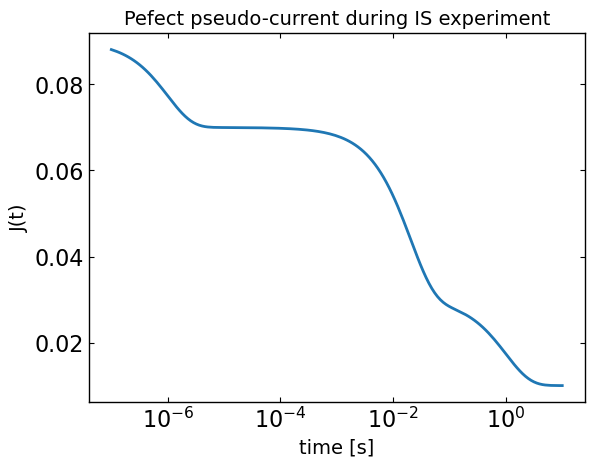

In [2]:
# Generate a perfect sum of exponential functions
U_perfect = [0.02, 0.04, 0.02]
tau_perfect = [1e-6, 2e-2, 1e0]
offset_perfect = 0.01

m_dec = 20 # number of time points per decade
t_min = 1e-7
t_max = 1e1
decades = np.log10(t_max/t_min)

time = np.geomspace(t_min, t_max, int(m_dec*decades))
perfect_DRT_curve = drt.DRT_curve(time, U_perfect, tau_perfect, offset=offset_perfect)

# Plot the curve
plt.plot(time, perfect_DRT_curve, label='Perfect')
plt.title("Pefect pseudo-current during IS experiment")
plt.xlabel("time [s]")
plt.ylabel("J(t)")
plt.xscale('log')
plt.plot()

In [3]:
# Try fitting the function with no scaling
U_scale_factor = perfect_DRT_curve.max() - perfect_DRT_curve.min()
offset0 = perfect_DRT_curve.min()
alpha = 0
drt_linear = drt.fit_DRT_curve_linear_torch(time, perfect_DRT_curve, time, U_scale_factor=U_scale_factor, offset=offset0, alpha=alpha, max_iter=1000)

[]

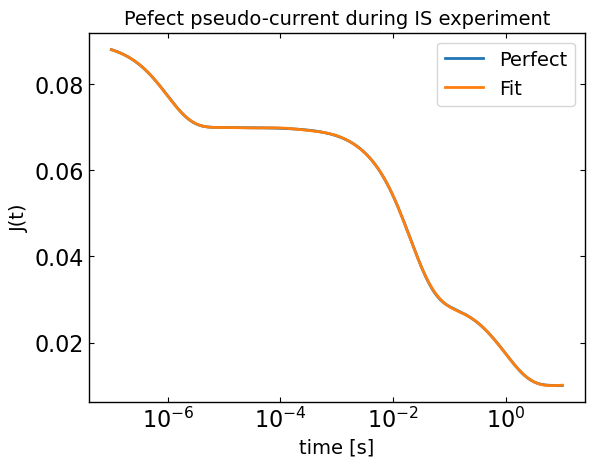

In [4]:
# Plot the curve
plt.plot(time, perfect_DRT_curve, label='Perfect')
plt.plot(time, drt_linear.DRT_curve, label='Fit')
plt.title("Pefect pseudo-current during IS experiment")
plt.xlabel("time [s]")
plt.ylabel("J(t)")
plt.xscale('log')
plt.legend()
plt.plot()

[]

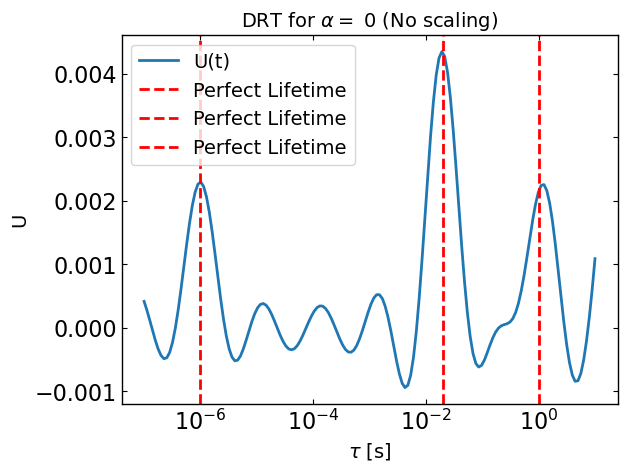

In [5]:
plt.plot(time, drt_linear.U, label='U(t)')
for tau_value in tau_perfect:
    plt.axvline(tau_value, linestyle='--', color='red', label='Perfect Lifetime')
plt.title(f"DRT for $\\alpha =$ {alpha} (No scaling)")
plt.xlabel("$\\tau$ [s]")
plt.ylabel("U")
plt.xscale('log')
plt.legend()
plt.plot()

We can clearly see this works as a fit. Let's check what this looks like for varying levels of alpha.

In [6]:
# Alpha value range 
alpha_values = np.geomspace(1e-3, 1e1, 10)
fits_linear_alpha = []

for alpha_value in alpha_values:
    drt_linear = drt.fit_DRT_curve_linear_torch(time, perfect_DRT_curve, time, U_scale_factor=U_scale_factor, offset=offset0, alpha=alpha_value, max_iter=1000)
    fits_linear_alpha.append(drt_linear)

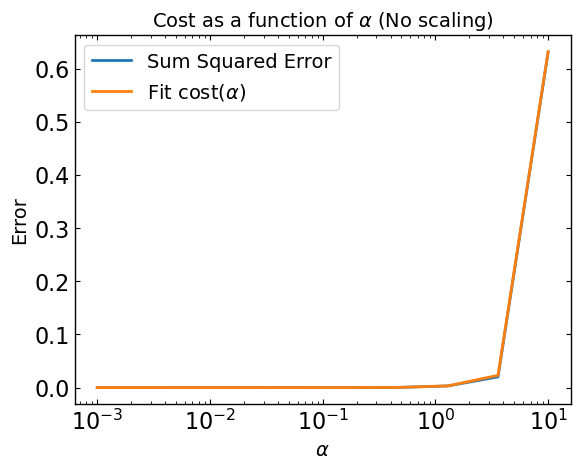

In [7]:
# Let's look at both MSE and the cost for each value of alpha
SSE_values = []
fit_cost_values = []

for i in range(len(fits_linear_alpha)):
    fit = fits_linear_alpha[i]
    SSE = np.sum((fit.DRT_curve - perfect_DRT_curve)**2)
    SSE_values.append(SSE)
    fit_cost_values.append(fit.cost)

plt.plot(alpha_values, SSE_values, label='Sum Squared Error')
plt.plot(alpha_values, fit_cost_values, label='Fit cost($\\alpha$)')

plt.title(f"Cost as a function of $\\alpha$ (No scaling)")
plt.xlabel("$\\alpha$")
plt.ylabel("Error")
plt.xscale('log')
plt.legend()
plt.show()


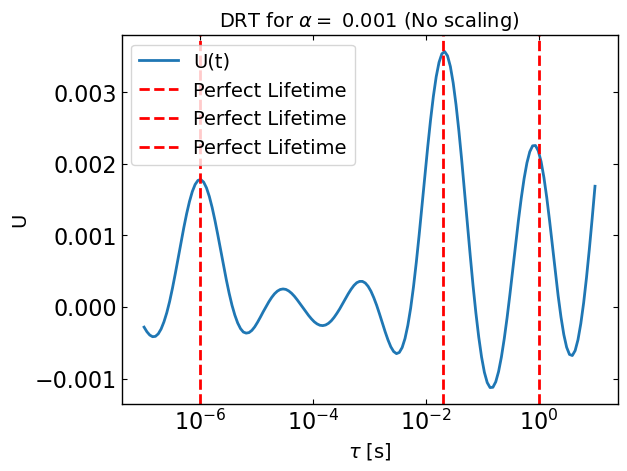

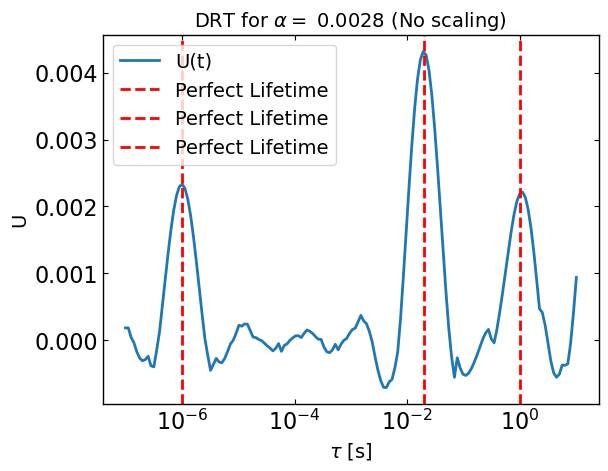

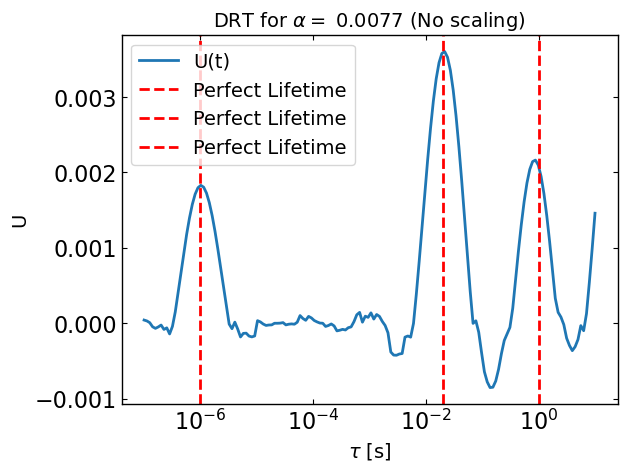

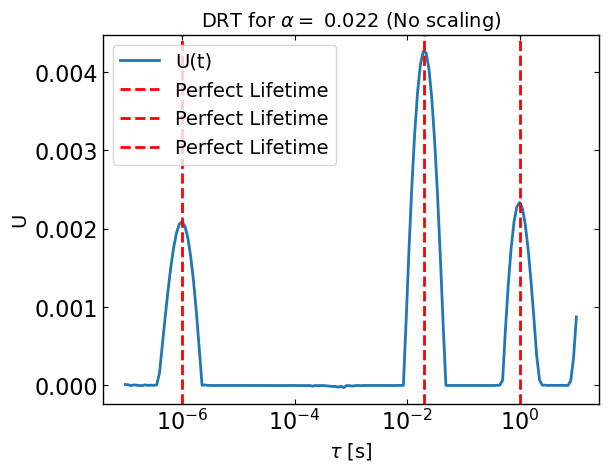

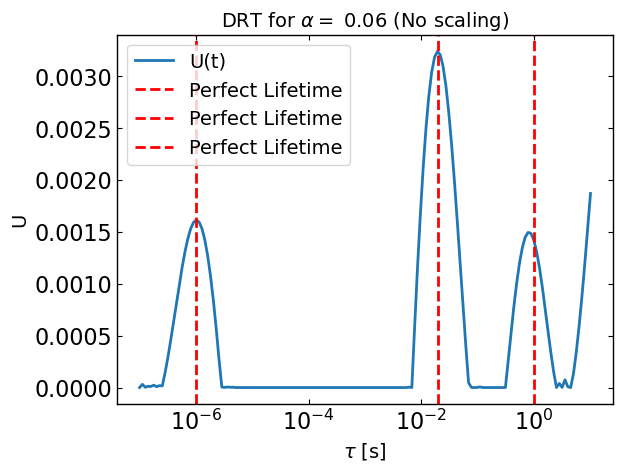

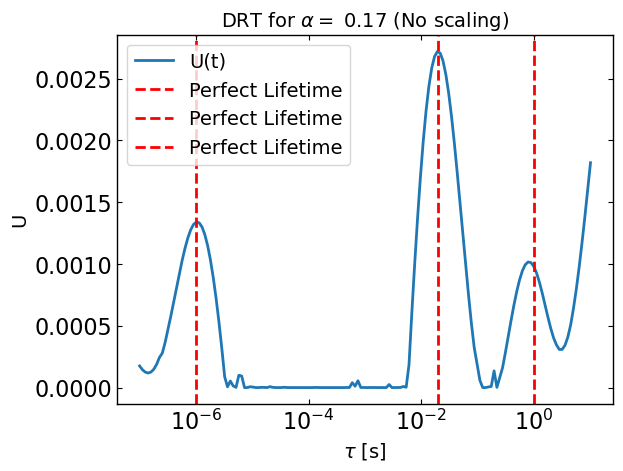

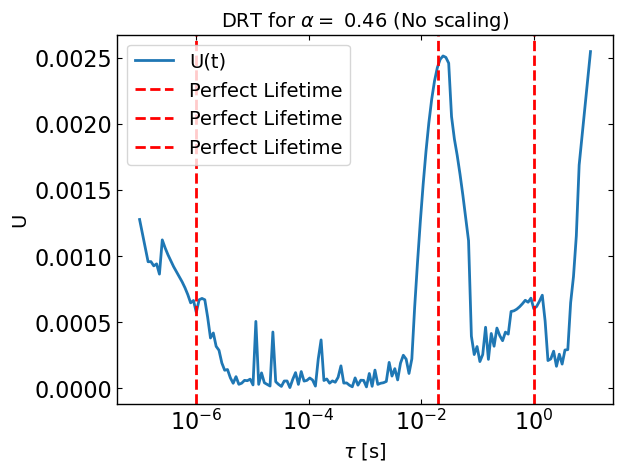

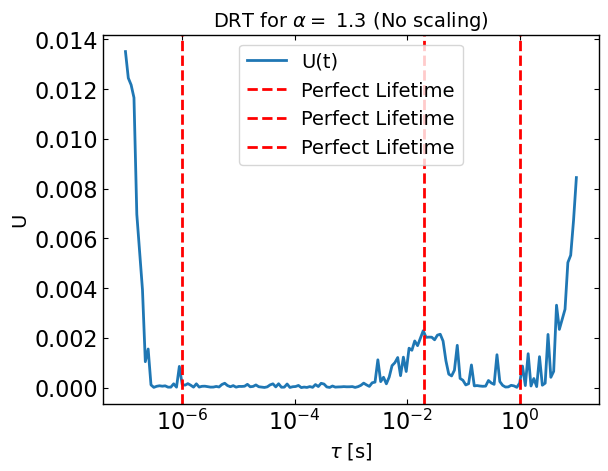

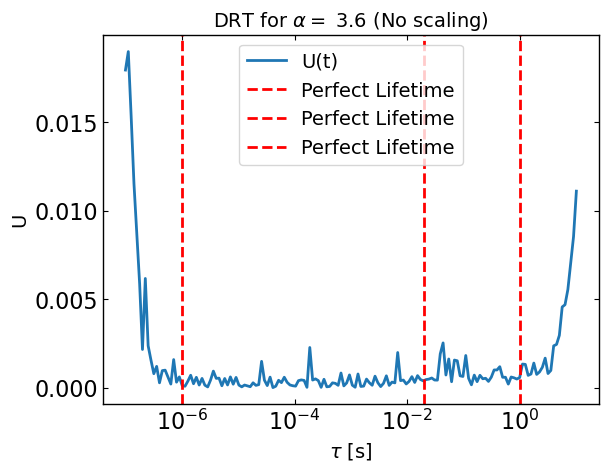

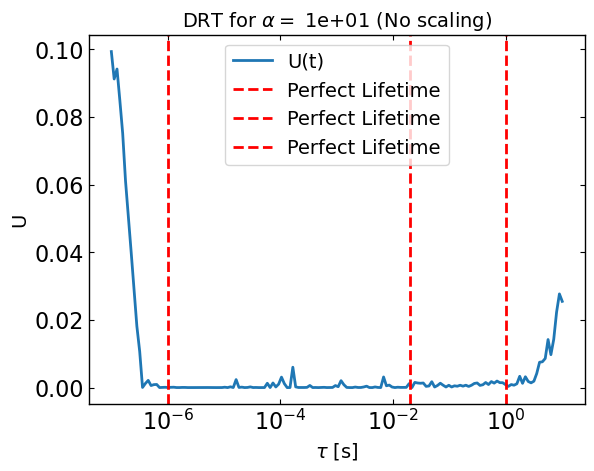

In [8]:
for i in range(len(fits_linear_alpha)):
    fit = fits_linear_alpha[i]
    plt.plot(time, fit.U, label='U(t)')
    for tau_value in tau_perfect:
        plt.axvline(tau_value, linestyle='--', color='red', label='Perfect Lifetime')
    plt.title(f"DRT for $\\alpha =$ {alpha_values[i]:.2} (No scaling)")
    plt.xlabel("$\\tau$ [s]")
    plt.ylabel("U")
    plt.xscale('log')
    plt.legend()
    plt.show()

### Applying scaling

[]

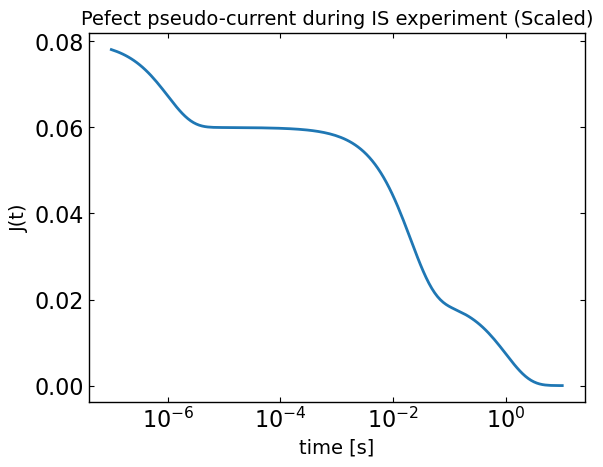

In [9]:
perfect_DRT_curve_scaled = (perfect_DRT_curve - perfect_DRT_curve.min())

# Plot the curve
plt.plot(time, perfect_DRT_curve_scaled, label='Perfect')
plt.title("Pefect pseudo-current during IS experiment (Scaled)")
plt.xlabel("time [s]")
plt.ylabel("J(t)")
plt.xscale('log')
plt.plot()

In [10]:
# Try fitting the function with no scaling
U_scale_factor = perfect_DRT_curve_scaled.max() - perfect_DRT_curve_scaled.min()
offset0 = perfect_DRT_curve_scaled.min()
alpha = 0
drt_linear_scaled = drt.fit_DRT_curve_linear_torch(time, perfect_DRT_curve_scaled, time, U_scale_factor=U_scale_factor, offset=offset0, alpha=alpha, max_iter=1000)

[]

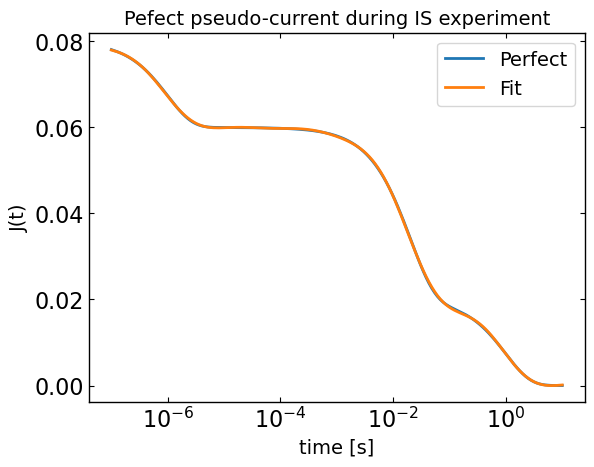

In [11]:
# Plot the curve
plt.plot(time, perfect_DRT_curve_scaled, label='Perfect')
plt.plot(time, drt_linear_scaled.DRT_curve, label='Fit')
plt.title("Pefect pseudo-current during IS experiment")
plt.xlabel("time [s]")
plt.ylabel("J(t)")
plt.xscale('log')
plt.legend()
plt.plot()

[]

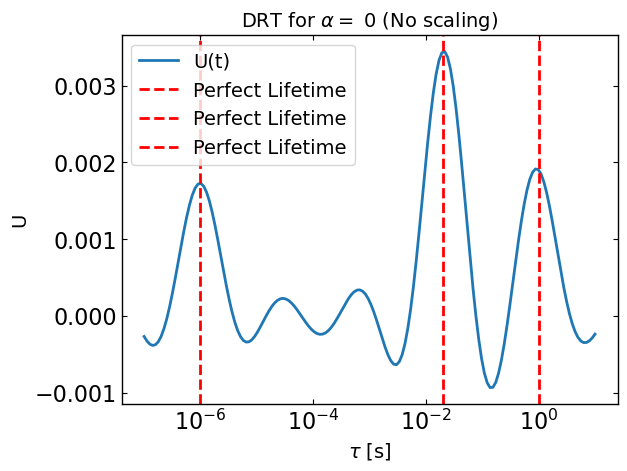

In [12]:
plt.plot(time, drt_linear_scaled.U, label='U(t)')
for tau_value in tau_perfect:
    plt.axvline(tau_value, linestyle='--', color='red', label='Perfect Lifetime')
plt.title(f"DRT for $\\alpha =$ {alpha} (No scaling)")
plt.xlabel("$\\tau$ [s]")
plt.ylabel("U")
plt.xscale('log')
plt.legend()
plt.plot()

In [13]:
fits_linear_alpha_scaled = []
for alpha_value in alpha_values:
    drt_linear_scaled = drt.fit_DRT_curve_linear_torch(time, perfect_DRT_curve_scaled, time, U_scale_factor=U_scale_factor, offset=offset0, alpha=alpha_value, max_iter=1000)
    fits_linear_alpha_scaled.append(drt_linear_scaled)

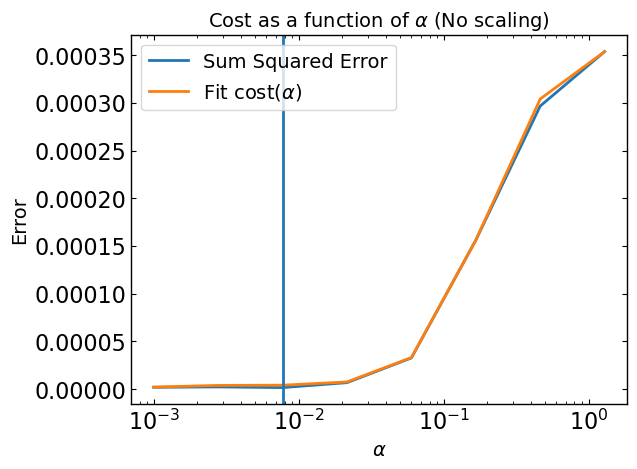

Best alpha according to SSE: 0.007742636826811269
Best alpha according to fit cost: 0.001


In [14]:
# Let's look at both MSE and the cost for each value of alpha
index = 8
SSE_values_scaled = []
fit_cost_values_scaled = []

for i in range(len(fits_linear_alpha_scaled))[:index]:
    fit = fits_linear_alpha_scaled[i]
    SSE = np.sum((fit.DRT_curve - perfect_DRT_curve_scaled)**2)
    SSE_values_scaled.append(SSE)
    fit_cost_values_scaled.append(fit.cost)

plt.plot(alpha_values[:index], SSE_values_scaled, label='Sum Squared Error')
plt.plot(alpha_values[:index], fit_cost_values_scaled, label='Fit cost($\\alpha$)')
plt.axvline(alpha_values[np.argmin(SSE_values_scaled)])

plt.title(f"Cost as a function of $\\alpha$ (No scaling)")
plt.xlabel("$\\alpha$")
plt.ylabel("Error")
plt.xscale('log')
plt.legend()
plt.show()

print(f"Best alpha according to SSE: {alpha_values[np.argmin(SSE_values_scaled)]}")
print(f"Best alpha according to fit cost: {alpha_values[np.argmin(fit_cost_values_scaled)]}")

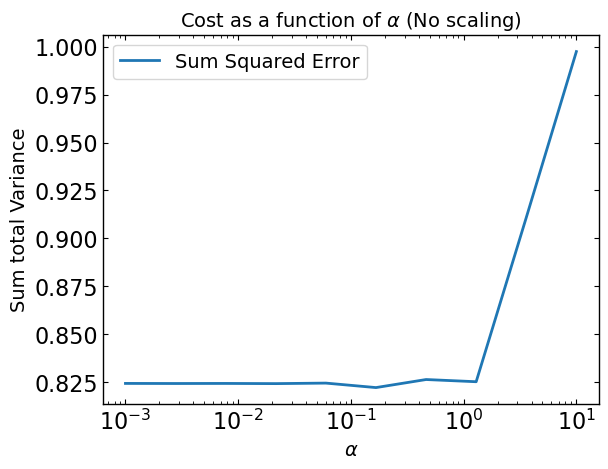

Best alpha according to sum of derivatives: 0.007742636826811269
Best alpha according to mean abs value: 10.0
Best alpha according to R^2 criteria: 0.1668100537200059


In [44]:
# Let's look at the sum of the variance at each point
variance_values = []
abs_values = []
mean_abs_values = []
median_abs_values = []
derivatives = []
mu_values = []
snr_values = []
peak_counts = []
snr_2_values = []

for i in range(len(fits_linear_alpha_scaled)):
    fit = fits_linear_alpha_scaled[i]
    variance = np.var(fit.DRT_curve)
    abs_value = np.sum(np.abs(fit.DRT_curve))
    mean_abs_value = np.mean(np.abs(fit.DRT_curve))
    median_abs_value = np.median(np.abs(fit.DRT_curve))
    sum_abs_derivatives = np.sum(np.abs(np.gradient(fit.DRT_curve))) # Looks promising
    mu = np.sum(np.abs(fit.U[np.where(fit.U < 0)]))/np.sum(np.abs(fit.U[np.where(fit.U >= 0)]))
    snr = np.mean(fit.DRT_curve)/np.std(fit.DRT_curve)
    snr_2 = np.sum(fit.U)/np.sum(np.abs(fit.U))
    no_peaks = np.sum([1 if fit.U[i-1] < fit.U[i] and fit.U[i+1] < fit.U[i] else 0 for i in range(len(fit.U))[1:-1]])
    
    mu_values.append(mu)
    derivatives.append(sum_abs_derivatives)
    variance_values.append(variance)
    mean_abs_values.append(mean_abs_value)
    median_abs_values.append(median_abs_value)
    abs_values.append(abs_value)
    snr_values.append(snr)
    snr_2_values.append(snr_2)
    peak_counts.append(no_peaks)

R_squared = 1 - np.mean(SSE_values_scaled)/variance_values
# plt.plot(alpha_values[:5], variance_values, label='Sum Squared Error')
plt.plot(alpha_values, R_squared, label='Sum Squared Error')

plt.title(f"Cost as a function of $\\alpha$ (No scaling)")
plt.xlabel("$\\alpha$")
plt.ylabel("Sum total Variance")
plt.xscale('log')
plt.legend()
plt.show()

print(f"Best alpha according to sum of derivatives: {alpha_values[np.argmin(derivatives)]}")
print(f"Best alpha according to mean abs value: {alpha_values[np.argmax(mean_abs_values)]}")
print(f"Best alpha according to R^2 criteria: {alpha_values[np.argmax(R_squared+snr_values)]}")

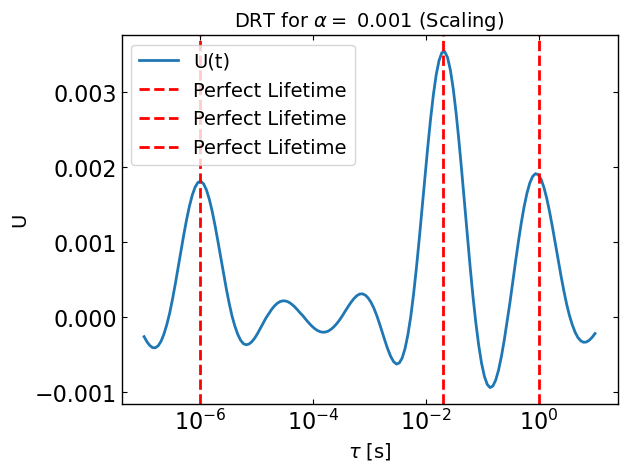

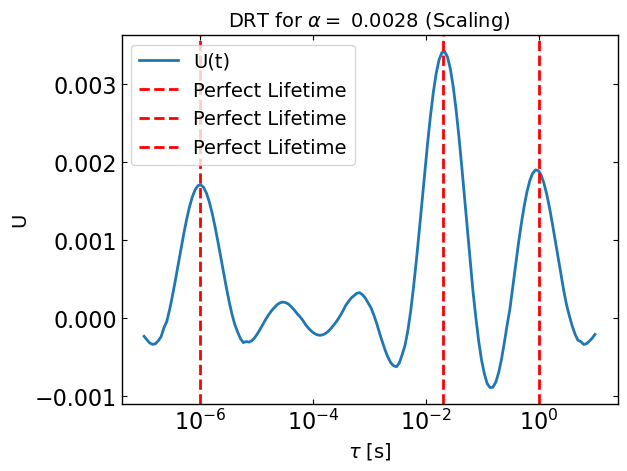

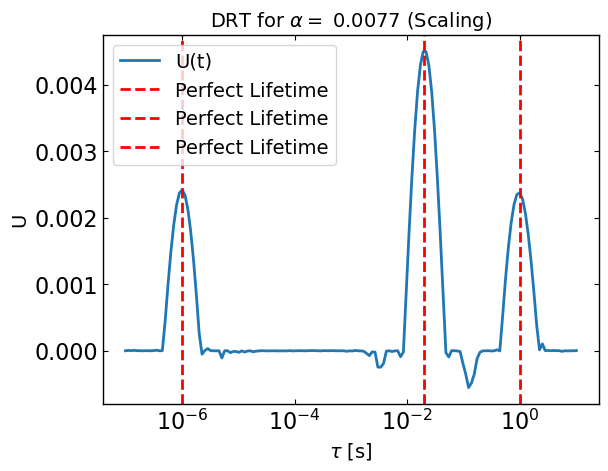

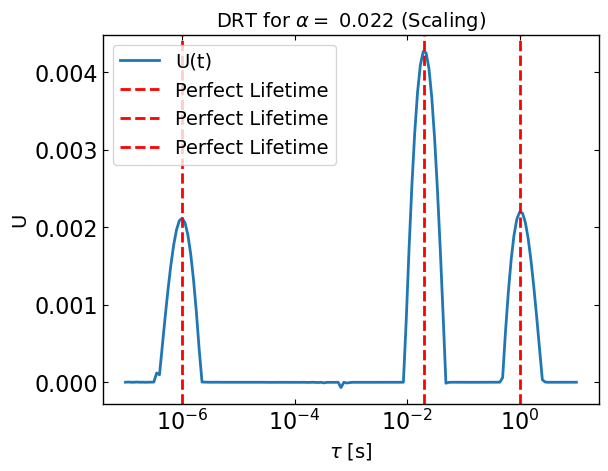

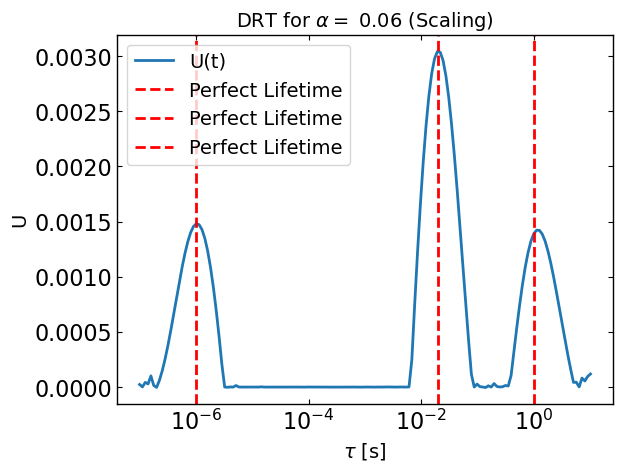

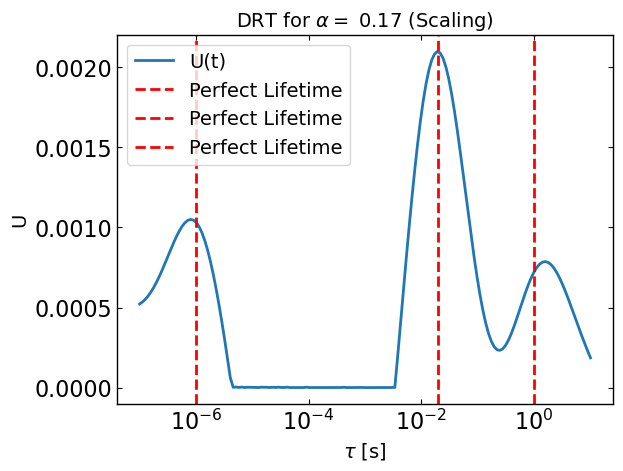

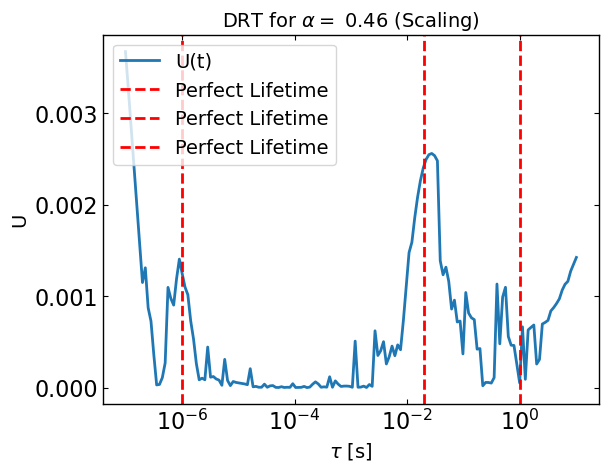

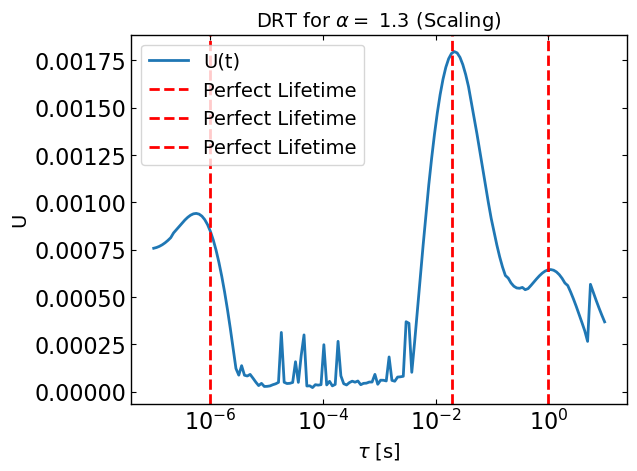

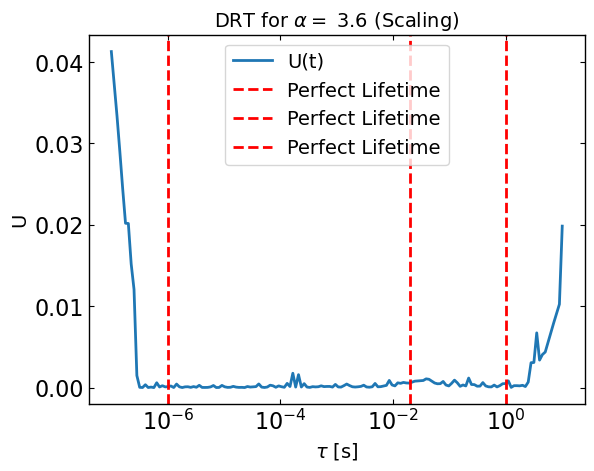

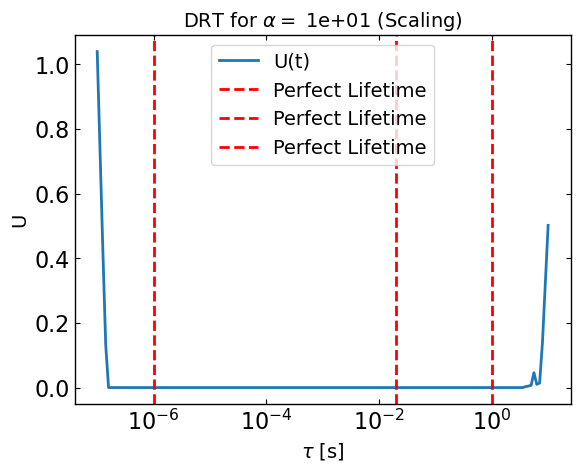

In [16]:
for i in range(len(fits_linear_alpha_scaled)):
    fit = fits_linear_alpha_scaled[i]
    plt.plot(time, fit.U, label='U(t)')
    for tau_value in tau_perfect:
        plt.axvline(tau_value, linestyle='--', color='red', label='Perfect Lifetime')
    plt.title(f"DRT for $\\alpha =$ {alpha_values[i]:.2} (Scaling)")
    plt.xlabel("$\\tau$ [s]")
    plt.ylabel("U")
    plt.xscale('log')
    plt.legend()
    plt.show()

[[-2.6252907e-04 -3.3008761e-04 -3.8016215e-04 ... -3.0914252e-04
  -2.7100430e-04 -2.2072475e-04]
 [-2.2943314e-04 -2.7497357e-04 -3.1484634e-04 ... -2.9180714e-04
  -2.5345493e-04 -2.0501985e-04]
 [-1.5275683e-07  5.7279440e-06  9.1045933e-07 ...  1.0646279e-07
  -4.0046484e-07  2.8297770e-06]
 ...
 [ 7.5772195e-04  7.6174998e-04  7.6780602e-04 ...  4.4304755e-04
   4.0497980e-04  3.6892574e-04]
 [ 4.1275039e-02  3.7389029e-02  3.3353776e-02 ...  9.1267489e-03
   1.0243751e-02  1.9836294e-02]
 [ 1.0388293e+00  7.3207378e-01  4.2158949e-01 ...  1.3922527e-01
   3.2030538e-01  5.0156331e-01]]


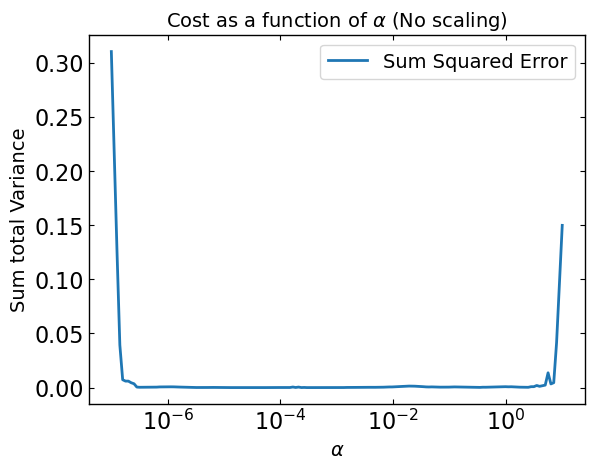

In [17]:
# Perform alpha sweep to check variance as these parameters change 
fits_linear_alpha_scaled_arr = np.array([fit.U for fit in fits_linear_alpha_scaled])
print(fits_linear_alpha_scaled_arr)

variance_alpha = np.std(fits_linear_alpha_scaled_arr, axis=0)

plt.plot(time, variance_alpha, label='Sum Squared Error')

plt.title(f"Cost as a function of $\\alpha$ (No scaling)")
plt.xlabel("$\\alpha$")
plt.ylabel("Sum total Variance")
plt.xscale('log')
plt.legend()
plt.show()